<a href="https://colab.research.google.com/github/sudarshinib2405-sys/CUSTOMER-CHURN-PREDICTION/blob/main/Churn_Detection_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# BANK CUSTOMER CHURN PREDICTION
# Dataset: shantanudhakadd/bank-customer-churn-prediction
# ============================================================


# ============================================================
# STEP 1: DOWNLOAD DATASET
# ============================================================

!kaggle datasets download -d shantanudhakadd/bank-customer-churn-prediction
!unzip bank-customer-churn-prediction.zip



Dataset URL: https://www.kaggle.com/datasets/shantanudhakadd/bank-customer-churn-prediction
License(s): other
100% 262k/262k [00:00<00:00, 136MB/s]

Archive:  bank-customer-churn-prediction.zip
  inflating: Churn_Modelling.csv     


In [ ]:
# ============================================================
# STEP 2: IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency, ttest_ind

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

import joblib

In [ ]:
# ============================================================
# STEP 3: LOAD DATASET
# ============================================================

df = pd.read_csv("Churn_Modelling.csv")

print(df.head())
print(df.shape)
print(df.info())


   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  
4         790

In [ ]:
# ============================================================
# STEP 4: DATA CLEANING
# ============================================================

df = df.drop_duplicates()

df = df.drop(["RowNumber", "CustomerId", "Surname"], axis=1)

print(df.isnull().sum())



CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [ ]:
# ============================================================
# STEP 5: MISSING VALUE HANDLING
# ============================================================

num_cols = df.select_dtypes(exclude=["object"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

df[num_cols] = df[num_cols].fillna(df[num_cols].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print(df.isnull().sum())


CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


Exited
0    7963
1    2037
Name: count, dtype: int64
Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


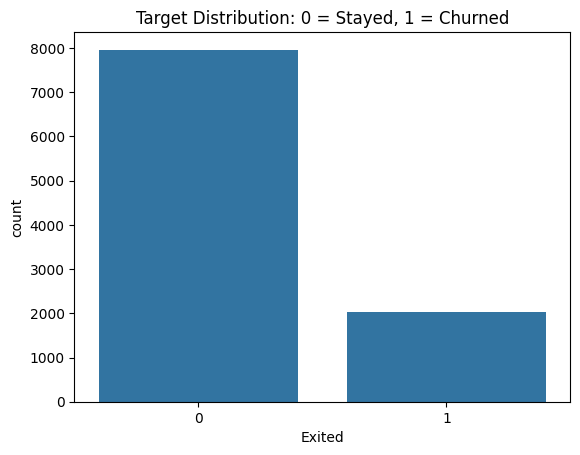

In [ ]:
# ============================================================
# STEP 6: EDA - TARGET DISTRIBUTION
# ============================================================

print(df["Exited"].value_counts())
print(df["Exited"].value_counts(normalize=True) * 100)

sns.countplot(x="Exited", data=df)
plt.title("Target Distribution: 0 = Stayed, 1 = Churned")
plt.show()


        CreditScore           Age        Tenure        Balance  NumOfProducts  \
count  10000.000000  10000.000000  10000.000000   10000.000000   10000.000000   
mean     650.528800     38.921800      5.012800   76485.889288       1.530200   
std       96.653299     10.487806      2.892174   62397.405202       0.581654   
min      350.000000     18.000000      0.000000       0.000000       1.000000   
25%      584.000000     32.000000      3.000000       0.000000       1.000000   
50%      652.000000     37.000000      5.000000   97198.540000       1.000000   
75%      718.000000     44.000000      7.000000  127644.240000       2.000000   
max      850.000000     92.000000     10.000000  250898.090000       4.000000   

         HasCrCard  IsActiveMember  EstimatedSalary        Exited  
count  10000.00000    10000.000000     10000.000000  10000.000000  
mean       0.70550        0.515100    100090.239881      0.203700  
std        0.45584        0.499797     57510.492818      0.402769 

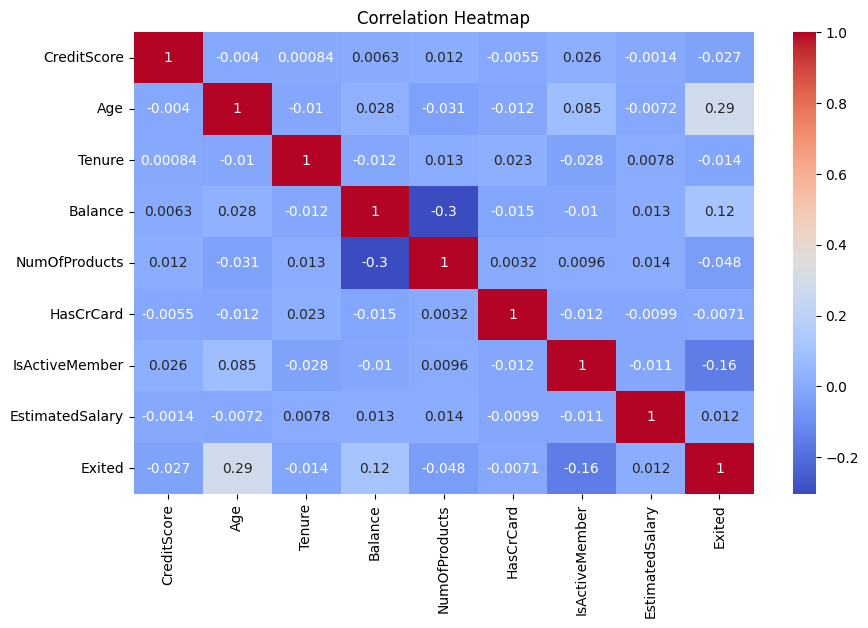

In [ ]:
# ============================================================
# STEP 7: EDA - NUMERICAL ANALYSIS
# ============================================================

print(df.describe())

plt.figure(figsize=(10, 6))
sns.heatmap(df.select_dtypes(exclude=["object"]).corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


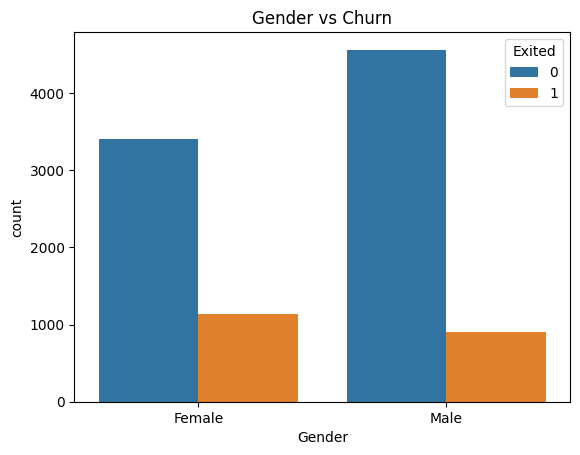

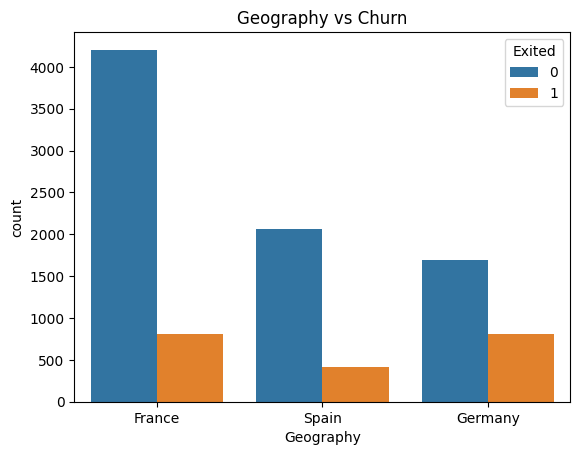

In [ ]:
# ============================================================
# STEP 8: EDA - CATEGORICAL VS TARGET
# ============================================================

sns.countplot(x="Gender", hue="Exited", data=df)
plt.title("Gender vs Churn")
plt.show()

sns.countplot(x="Geography", hue="Exited", data=df)
plt.title("Geography vs Churn")
plt.show()



In [ ]:
# ============================================================
# STEP 9: STATISTICAL TESTS
# ============================================================

# Chi-square test: categorical feature vs categorical target

for col in ["Gender", "Geography"]:
    table = pd.crosstab(df[col], df["Exited"])
    chi2, p, dof, expected = chi2_contingency(table)
    print(f"\nChi-square test for {col} vs Exited")
    print("p-value:", p)

# T-test: numerical feature vs binary target

for col in ["CreditScore", "Age", "Tenure", "Balance", "EstimatedSalary"]:
    group_0 = df[df["Exited"] == 0][col]
    group_1 = df[df["Exited"] == 1][col]
    t_stat, p_value = ttest_ind(group_0, group_1)
    print(f"\nT-test for {col} vs Exited")
    print("p-value:", p_value)



Chi-square test for Gender vs Exited
p-value: 2.2482100097131755e-26

Chi-square test for Geography vs Exited
p-value: 3.8303176053541544e-66

T-test for CreditScore vs Exited
p-value: 0.006738213892192373

T-test for Age vs Exited
p-value: 1.2399313093427736e-186

T-test for Tenure vs Exited
p-value: 0.16152684949473256

T-test for Balance vs Exited
p-value: 1.2755633191525477e-32

T-test for EstimatedSalary vs Exited
p-value: 0.22644042802223352


In [ ]:
# ============================================================
# STEP 10: IMPROVED FEATURE ENGINEERING
# ============================================================

# Existing features (keep if already present)
df["BalanceSalaryRatio"] = df["Balance"] / (df["EstimatedSalary"] + 1)
df["AgeTenureRatio"] = df["Age"] / (df["Tenure"] + 1)
df["ProductsPerTenure"] = df["NumOfProducts"] / (df["Tenure"] + 1)

# NEW FEATURES (IMPORTANT)

# 1. Balance vs Credit Score
df["Balance_to_Credit"] = df["Balance"] / (df["CreditScore"] + 1)

# 2. Active member impact
df["Active_Balance"] = df["IsActiveMember"] * df["Balance"]

# 3. Engagement score
df["EngagementScore"] = (
    df["IsActiveMember"] +
    df["NumOfProducts"] +
    df["HasCrCard"]
)
#4.Age Group
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 30, 45, 60, 100],
    labels=[0, 1, 2, 3],
    include_lowest=True
)

# 5. Estimated salary per product
df["Salary_per_Product"] = df["EstimatedSalary"] / (df["NumOfProducts"] + 1)

# 6. Tenure stability
df["TenureGroup"] = pd.cut(
    df["Tenure"],
    bins=[-1, 3, 6, 10],
    labels=[0, 1, 2],
    include_lowest=True
)

print(df.head())
print(df.isnull().sum())
df = df.fillna(0)

   CreditScore Geography  Gender  Age  Tenure    Balance  NumOfProducts  \
0          619    France  Female   42       2       0.00              1   
1          608     Spain  Female   41       1   83807.86              1   
2          502    France  Female   42       8  159660.80              3   
3          699    France  Female   39       1       0.00              2   
4          850     Spain  Female   43       2  125510.82              1   

   HasCrCard  IsActiveMember  EstimatedSalary  Exited  BalanceSalaryRatio  \
0          1               1        101348.88       1            0.000000   
1          0               1        112542.58       0            0.744670   
2          1               0        113931.57       1            1.401362   
3          0               0         93826.63       0            0.000000   
4          1               1         79084.10       0            1.587035   

   AgeTenureRatio  ProductsPerTenure  Balance_to_Credit  Active_Balance  \
0       14.

In [ ]:
# ============================================================
# STEP 11: SPLIT FEATURES AND TARGET
# ============================================================

X = df.drop("Exited", axis=1)

y = df["Exited"]

categorical_cols = X.select_dtypes(include=["object"]).columns

numerical_cols = X.select_dtypes(exclude=["object"]).columns

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

Categorical columns: Index(['Geography', 'Gender'], dtype='object')
Numerical columns: Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'BalanceSalaryRatio',
       'AgeTenureRatio', 'ProductsPerTenure', 'Balance_to_Credit',
       'Active_Balance', 'EngagementScore', 'AgeGroup', 'Salary_per_Product',
       'TenureGroup'],
      dtype='object')


In [ ]:
# ============================================================
# STEP 12: TRAIN-TEST SPLIT WITH STRATIFY
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
# ============================================================
# STEP 13: PREPROCESSING + SMOTE + RANDOM FOREST PIPELINE
# ============================================================

!pip install imbalanced-learn -q

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols)
    ]
)

rf_pipe = Pipeline([
    ("preprocessing", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(random_state=42, n_jobs=-1))
])

Best parameters: {'smote__sampling_strategy': 0.4, 'model__n_estimators': 500, 'model__min_samples_split': 10, 'model__min_samples_leaf': 1, 'model__max_depth': 8, 'model__class_weight': 'balanced'}
Final Accuracy: 0.8265
Final Precision: 0.5592885375494071
Final Recall: 0.6953316953316954
Final F1 Score: 0.619934282584885
Final ROC-AUC: 0.8588634859821301
              precision    recall  f1-score   support

           0       0.92      0.86      0.89      1593
           1       0.56      0.70      0.62       407

    accuracy                           0.83      2000
   macro avg       0.74      0.78      0.75      2000
weighted avg       0.84      0.83      0.83      2000



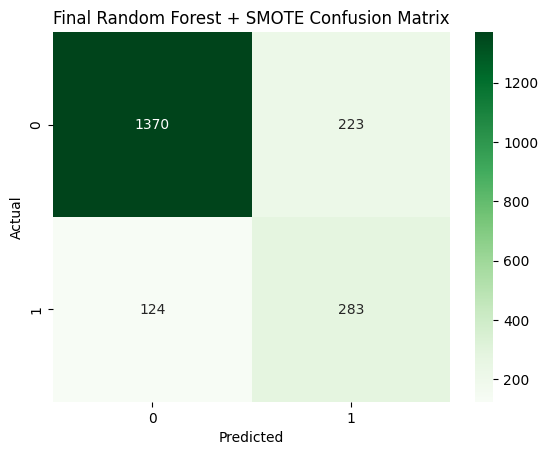

In [ ]:
# ============================================================
# STEP 14: HYPERPARAMETER TUNING
# ============================================================

params = {
    "smote__sampling_strategy": [0.4, 0.6, 0.8, 1.0],
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [8, 12, 16, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__class_weight": [None, "balanced"]
}

search = RandomizedSearchCV(
    rf_pipe,
    param_distributions=params,
    scoring="f1",
    cv=5,
    n_iter=15,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_churn_model = search.best_estimator_

print("Best parameters:", search.best_params_)

# ============================================================
# STEP 15: FINAL EVALUATION
# ============================================================

y_pred_final = best_churn_model.predict(X_test)

y_prob = best_churn_model.predict_proba(X_test)[:, 1]

print("Final Accuracy:", accuracy_score(y_test, y_pred_final))
print("Final Precision:", precision_score(y_test, y_pred_final))
print("Final Recall:", recall_score(y_test, y_pred_final))
print("Final F1 Score:", f1_score(y_test, y_pred_final))
print("Final ROC-AUC:", roc_auc_score(y_test, y_prob))

print(classification_report(y_test, y_pred_final))

cm = confusion_matrix(y_test, y_pred_final)

sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.title("Final Random Forest + SMOTE Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# ============================================================
# STEP 17: THRESHOLD TUNING
# ============================================================

y_prob = best_churn_model.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.05)

best_f1 = 0
best_threshold = 0.5

for threshold in thresholds:
    y_pred_threshold = (y_prob >= threshold).astype(int)
    f1 = f1_score(y_test, y_pred_threshold)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print("Best threshold:", best_threshold)
print("Best threshold F1:", best_f1)

Best threshold: 0.5000000000000001
Best threshold F1: 0.619934282584885


In [ ]:
# ============================================================
# RECALL-FOCUSED THRESHOLD TUNING
# ============================================================

y_prob = best_churn_model.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.1, 0.6, 0.05)

for threshold in thresholds:
    y_pred_threshold = (y_prob >= threshold).astype(int)

    print("Threshold:", round(threshold, 2))
    print("Accuracy:", accuracy_score(y_test, y_pred_threshold))
    print("Precision:", precision_score(y_test, y_pred_threshold))
    print("Recall:", recall_score(y_test, y_pred_threshold))
    print("F1:", f1_score(y_test, y_pred_threshold))
    print("-" * 40)

Threshold: 0.1
Accuracy: 0.2945
Precision: 0.2229580573951435
Recall: 0.9926289926289926
F1: 0.36412798557908965
----------------------------------------
Threshold: 0.15
Accuracy: 0.4015
Precision: 0.2512594458438287
Recall: 0.9803439803439803
F1: 0.4
----------------------------------------
Threshold: 0.2
Accuracy: 0.485
Precision: 0.27860696517412936
Recall: 0.9631449631449631
F1: 0.432194046306505
----------------------------------------
Threshold: 0.25
Accuracy: 0.577
Precision: 0.31784232365145226
Recall: 0.941031941031941
F1: 0.47518610421836227
----------------------------------------
Threshold: 0.3
Accuracy: 0.642
Precision: 0.3492682926829268
Recall: 0.8796068796068796
F1: 0.5
----------------------------------------
Threshold: 0.35
Accuracy: 0.705
Precision: 0.3942196531791908
Recall: 0.8378378378378378
F1: 0.5361635220125787
----------------------------------------
Threshold: 0.4
Accuracy: 0.7555
Precision: 0.444141689373297
Recall: 0.800982800982801
F1: 0.5714285714285714
-

Final Accuracy: 0.8265
Final Precision: 0.5592885375494071
Final Recall: 0.6953316953316954
Final F1 Score: 0.619934282584885
Final ROC-AUC: 0.8588634859821301
              precision    recall  f1-score   support

           0       0.92      0.86      0.89      1593
           1       0.56      0.70      0.62       407

    accuracy                           0.83      2000
   macro avg       0.74      0.78      0.75      2000
weighted avg       0.84      0.83      0.83      2000



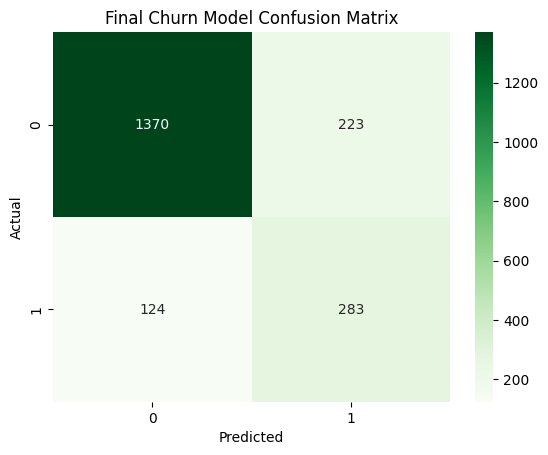

In [ ]:
# ============================================================
# STEP 18: FINAL EVALUATION
# ============================================================

y_pred_final = (y_prob >= best_threshold).astype(int)

print("Final Accuracy:", accuracy_score(y_test, y_pred_final))
print("Final Precision:", precision_score(y_test, y_pred_final))
print("Final Recall:", recall_score(y_test, y_pred_final))
print("Final F1 Score:", f1_score(y_test, y_pred_final))
print("Final ROC-AUC:", roc_auc_score(y_test, y_prob))

print(classification_report(y_test, y_pred_final))

cm = confusion_matrix(y_test, y_pred_final)

sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.title("Final Churn Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



In [ ]:
# ============================================================
# STEP 19: SAVE FINAL MODEL
# ============================================================

joblib.dump(best_churn_model, "bank_churn_model.pkl")

print("Bank churn model saved successfully!")

Bank churn model saved successfully!


In [ ]:
# ============================================================
# STEP 20: MODEL COMPARISON GRAPH (LR vs RF)
# ============================================================

from sklearn.base import clone

# Define the SAME models you used
model_defs = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
}

results = {}

for name, model in model_defs.items():
    # Build pipeline (same preprocessor you already defined)
    pipe = Pipeline([
        ("preprocessing", preprocessor),
        ("model", model)
    ])

    # Train
    pipe.fit(X_train, y_train)

    # Predict labels and probabilities
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    # Compute metrics
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

# Convert to DataFrame for easy plotting
results_df = pd.DataFrame(results).T
print(results_df)

                     Accuracy  Precision    Recall  F1-score   ROC-AUC
Logistic Regression     0.714   0.391874  0.734644  0.511111  0.786872
Random Forest           0.866   0.806167  0.449631  0.577287  0.852238


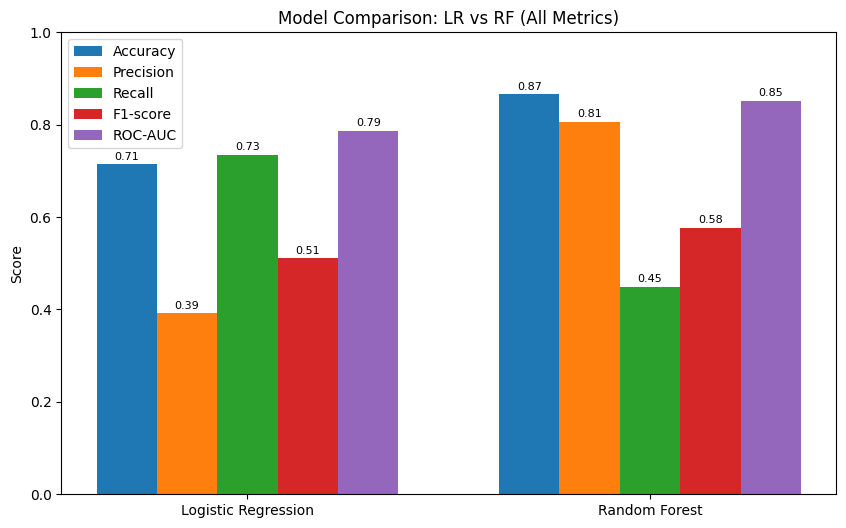

In [ ]:
# ============================================================
# PLOT: GROUPED BAR CHART
# ============================================================

plt.figure(figsize=(10,6))

x = np.arange(len(results_df.index))  # models
width = 0.15

for i, metric in enumerate(results_df.columns):
    plt.bar(x + i*width, results_df[metric], width, label=metric)

plt.xticks(x + width*2, results_df.index)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Model Comparison: LR vs RF (All Metrics)")
plt.legend()

# Add value labels
for i, metric in enumerate(results_df.columns):
    for j, val in enumerate(results_df[metric]):
        plt.text(j + i*width, val + 0.01, f"{val:.2f}", ha='center', fontsize=8)

plt.show()